# Dataset Overview

Having a land plot (30m × 30m) and by collecting some information about it (elevation, soil, distance, etc.) to predict the type of tree growing there

#Import Needed Libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# Import Dataset

In [ ]:
df = pd.read_csv("covtype.csv")

Detect Data Shape(number_of_rows, columns)

In [ ]:
df.shape

(581012, 55)

View Sample

In [ ]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


This table represent:
Each row = one geographic point (a patch of land),
Each column = a feature describing that land,
Last column (Cover_Type) = the label you want to predict

Display Dataset Features

In [ ]:
cols = df.columns
cols

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40


This shows the **names of all columns** in the dataset.

## Main groups of features:

### 1. Terrain features

* Elevation = height above sea level
* Aspect = slope direction
* Slope = steepness of the land

### 2. Distance features

* Distance to water
* Distance to roads
* Distance to fire points

### 3. Light (Hillshade) features

* Hillshade_9am, Hillshade_Noon, Hillshade_3pm
  , sunlight intensity at different times of the day

### 4. Wilderness areas

* Wilderness_Area -> 1–4 : one-hot encoded location of forest region

### 5. Soil types

* Soil_Type1 – Soil_Type40 : one-hot encoded soil categories

**one-hot encoded** Because both are categorical (not numeric) and don't have mathematical meaning or order , so the model avoids fake ordering between categories & improves model accuracy & makes features easier to interpret
### 6. Target column

* Cover_Type =  the tree type we want to predict

## *All these columns are used to predict the type of forest cover based on terrain, soil, and location features*


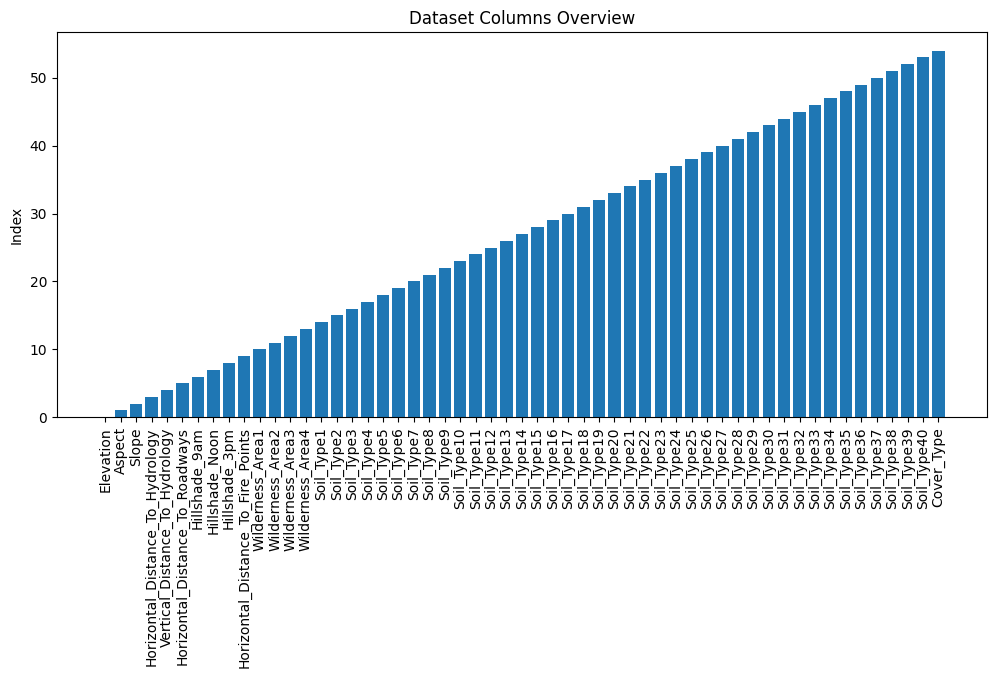

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(cols, range(len(cols)))

plt.xticks(rotation=90)
plt.title("Dataset Columns Overview")
plt.ylabel("Index")
plt.show()

#Display Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

# The data contains
1. Environment info (10 features)
e.g.
* Height of land (Elevation)
* Slope and direction (Aspect, Slope)
* Distance to water, roads, fire points
* Sunlight at different times (Hillshade)

2. Area type (4 features)
Which wilderness region the land belongs to (0 or 1 values)

3. Soil type (40 features)

* Each column shows if a soil type exists (Yes = 1, No = 0)

# Target

Cover_Type = type of forest/trees in that area

Idea : We are using **land features (soil + environment)** to predict **what type of forest is there**.

# Determine Missing values

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
data = df.copy()

#Splitting Data to prevent data leakage

In [ ]:
#Split full data into training(80%) and testing(20%) sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

df = train_data.copy()
data_test = test_data.copy()

# Determine the types of Features

In [ ]:
numeric_cols = []
binary_cols = []
categorical_cols = []

for col in df.columns:

    unique_vals = df[col].dropna().unique()
    n_unique = len(unique_vals)

    # Binary:  0 or 1
    if set(unique_vals).issubset({0, 1}):
        binary_cols.append(col)

    # Numeric
    elif pd.api.types.is_numeric_dtype(df[col]):
        numeric_cols.append(col)

    # Categorical
    else:
        categorical_cols.append(col)


print(" Numeric Features:", len(numeric_cols))
print(numeric_cols[:10])

print("\n Binary Features:", len(binary_cols))
print(binary_cols[:10])

print("\n Categorical Features:", len(categorical_cols))
print(categorical_cols)

 Numeric Features: 11
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

 Binary Features: 44
['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6']

 Categorical Features: 0
[]


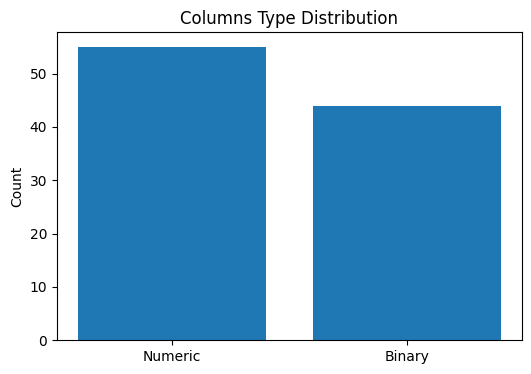

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
binary_cols = [c for c in df.columns if set(df[c].dropna().unique()).issubset({0,1})]

categories = ['Numeric', 'Binary']
counts = [len(numeric_cols), len(binary_cols)]

plt.figure(figsize=(6,4))
plt.bar(categories, counts)

plt.title("Columns Type Distribution")
plt.ylabel("Count")
plt.show()

# Determine number of unique values for each feature

In [ ]:
unique_df = pd.DataFrame({
    "Column": cols,
    "Unique Values": df.nunique().values
})

print(unique_df)

                                Column  Unique Values
0                            Elevation           1967
1                               Aspect            361
2                                Slope             66
3     Horizontal_Distance_To_Hydrology            545
4       Vertical_Distance_To_Hydrology            680
5      Horizontal_Distance_To_Roadways           5747
6                        Hillshade_9am            206
7                       Hillshade_Noon            182
8                        Hillshade_3pm            255
9   Horizontal_Distance_To_Fire_Points           5794
10                    Wilderness_Area1              2
11                    Wilderness_Area2              2
12                    Wilderness_Area3              2
13                    Wilderness_Area4              2
14                          Soil_Type1              2
15                          Soil_Type2              2
16                          Soil_Type3              2
17                          

# Display sample of it

In [ ]:
for col in cols:
    print(col, df[col].unique()[:5])

Elevation [3289 2963 3037 3113 3128]
Aspect [ 22  21 185 203 346]
Slope [19 18  9 13 32]
Horizontal_Distance_To_Hydrology [240 134 127 190 120]
Vertical_Distance_To_Hydrology [93 27 10 22 36]
Horizontal_Distance_To_Roadways [1708 1243 6462 2125  552]
Hillshade_9am [205 206 222 213 203]
Hillshade_Noon [196 200 246 251 226]
Hillshade_3pm [122 127 158 171 161]
Horizontal_Distance_To_Fire_Points [2598 1140 3037  730  924]
Wilderness_Area1 [0 1]
Wilderness_Area2 [0 1]
Wilderness_Area3 [1 0]
Wilderness_Area4 [0 1]
Soil_Type1 [0 1]
Soil_Type2 [0 1]
Soil_Type3 [0 1]
Soil_Type4 [0 1]
Soil_Type5 [0 1]
Soil_Type6 [0 1]
Soil_Type7 [0 1]
Soil_Type8 [0 1]
Soil_Type9 [0 1]
Soil_Type10 [0 1]
Soil_Type11 [0 1]
Soil_Type12 [0 1]
Soil_Type13 [0 1]
Soil_Type14 [0 1]
Soil_Type15 [0 1]
Soil_Type16 [0 1]
Soil_Type17 [0 1]
Soil_Type18 [0 1]
Soil_Type19 [0 1]
Soil_Type20 [0 1]
Soil_Type21 [0 1]
Soil_Type22 [0 1]
Soil_Type23 [0 1]
Soil_Type24 [0 1]
Soil_Type25 [0 1]
Soil_Type26 [0 1]
Soil_Type27 [0 1]
Soil_Type

# Features Value Range

In [ ]:
def get_feature_ranges(df):

    ranges = {}

    for col in cols:
        if df[col].dtype != 'object':

            col_min = df[col].min()
            col_max = df[col].max()

            ranges[col] = (col_min, col_max)

    return ranges

ranges = get_feature_ranges(df)

for k, v in ranges.items():
    print(f"{k}: min={v[0]}, max={v[1]}")

Elevation: min=1859, max=3858
Aspect: min=0, max=360
Slope: min=0, max=66
Horizontal_Distance_To_Hydrology: min=0, max=1397
Vertical_Distance_To_Hydrology: min=-166, max=601
Horizontal_Distance_To_Roadways: min=0, max=7117
Hillshade_9am: min=0, max=254
Hillshade_Noon: min=0, max=254
Hillshade_3pm: min=0, max=254
Horizontal_Distance_To_Fire_Points: min=0, max=7173
Wilderness_Area1: min=0, max=1
Wilderness_Area2: min=0, max=1
Wilderness_Area3: min=0, max=1
Wilderness_Area4: min=0, max=1
Soil_Type1: min=0, max=1
Soil_Type2: min=0, max=1
Soil_Type3: min=0, max=1
Soil_Type4: min=0, max=1
Soil_Type5: min=0, max=1
Soil_Type6: min=0, max=1
Soil_Type7: min=0, max=1
Soil_Type8: min=0, max=1
Soil_Type9: min=0, max=1
Soil_Type10: min=0, max=1
Soil_Type11: min=0, max=1
Soil_Type12: min=0, max=1
Soil_Type13: min=0, max=1
Soil_Type14: min=0, max=1
Soil_Type15: min=0, max=1
Soil_Type16: min=0, max=1
Soil_Type17: min=0, max=1
Soil_Type18: min=0, max=1
Soil_Type19: min=0, max=1
Soil_Type20: min=0, max=1

# Display Statistical Informations

mean = average
, std = spread
, min/max = limits
, quartiles = distribution split points

In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,...,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000
mean,2959.064317,155.614248,14.097795,269.317737,46.370707,2350.324359,212.154920,223.316625,142.521552,1980.727273,...,0.090381,0.077714,0.002747,0.003287,0.000213,0.000516,0.026774,0.023866,0.014944,2.052221
std,280.114776,111.904089,7.486642,212.463863,58.272807,1559.597183,26.757561,19.768404,38.241317,1325.421572,...,0.286727,0.267721,0.052343,0.057241,0.014593,0.022717,0.161424,0.152631,0.121328,1.397242
min,1859.000000,0.000000,0.000000,0.000000,-166.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1104.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2995.000000,127.000000,13.000000,218.000000,29.000000,1996.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3331.000000,231.000000,237.000000,168.000000,2549.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


# Display Outliers and data ranges

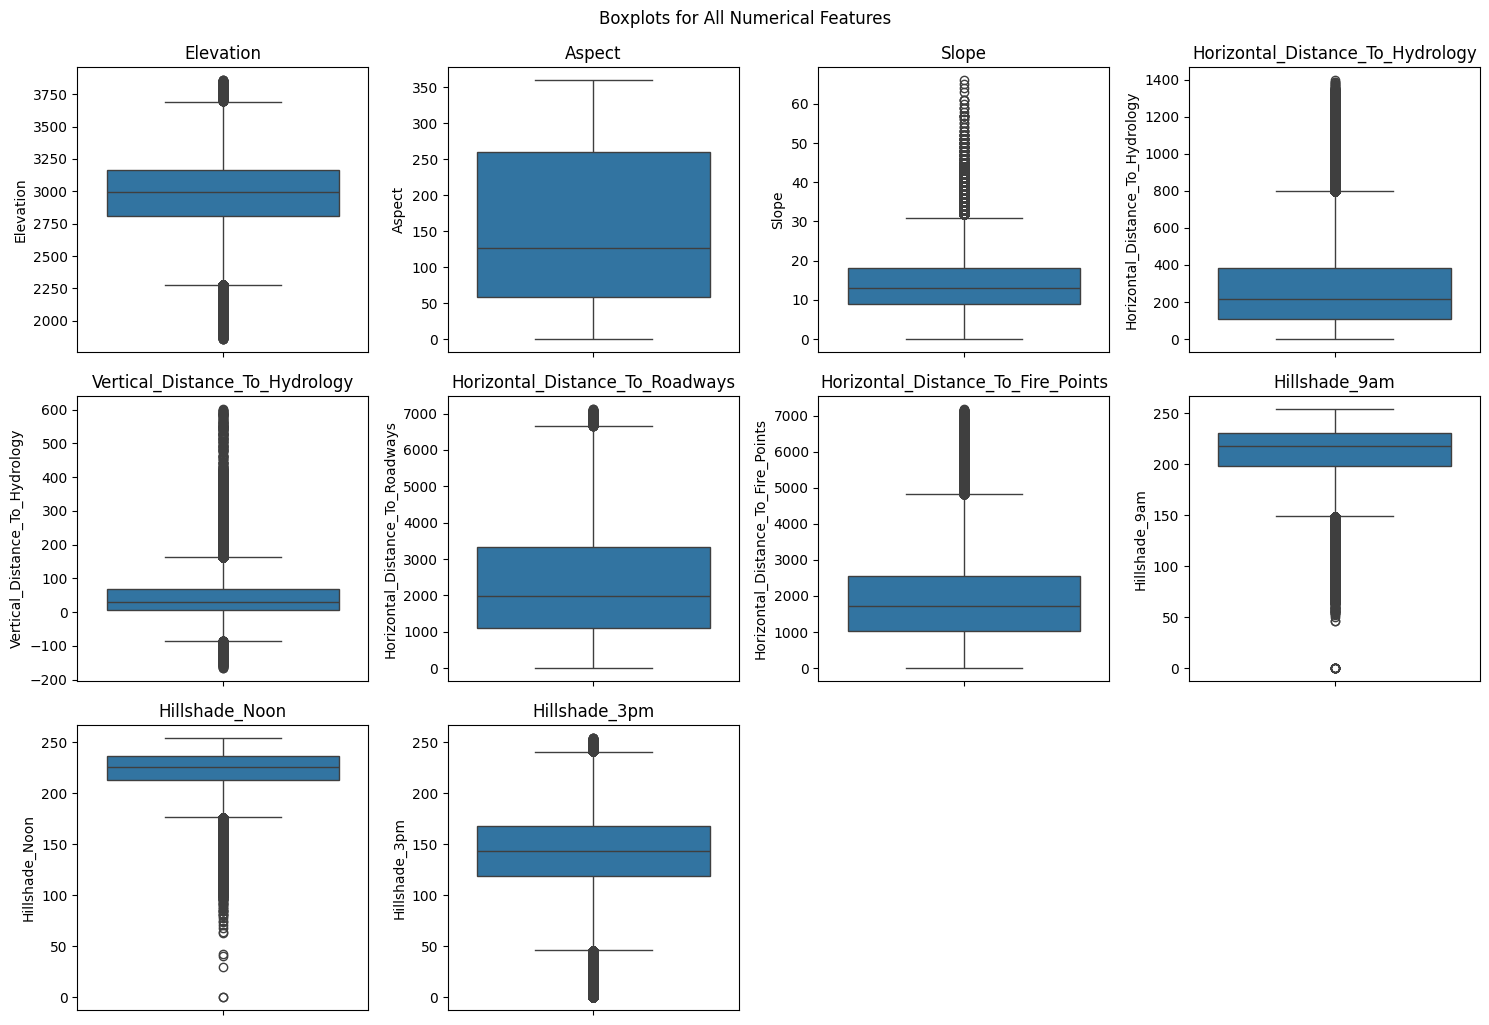

In [ ]:
features = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Horizontal_Distance_To_Fire_Points',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()

plt.suptitle("Boxplots for All Numerical Features", y=1.02)
plt.show()

It seems that the data contains outliers

# Categorize Numeric Features

In [ ]:
soil_cols = [col for col in df.columns if "Soil_Type" in col]
wilderness_cols = [col for col in df.columns if "Wilderness_Area" in col]

target_col = "Cover_Type"

print(wilderness_cols)
print(soil_cols)

['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']
['Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40']


In [ ]:
print("Wilderness Features:", len(wilderness_cols))
print("Soil Features:", len(soil_cols))

Wilderness Features: 4
Soil Features: 40


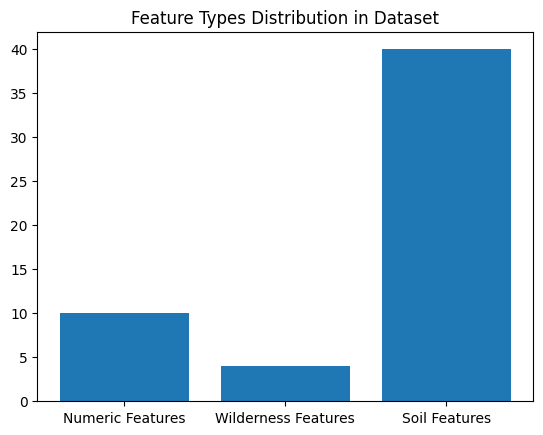

In [ ]:
numeric_cols = [c for c in numeric_cols if c not in soil_cols + wilderness_cols + [target_col]]

types = ["Numeric Features", "Wilderness Features", "Soil Features"]
counts = [len(numeric_cols), len(wilderness_cols), len(soil_cols)]

plt.figure()
plt.bar(types, counts)
plt.title("Feature Types Distribution in Dataset")
plt.show()


soil featuers have the largest number of columns in the data

# Display Numeric Features

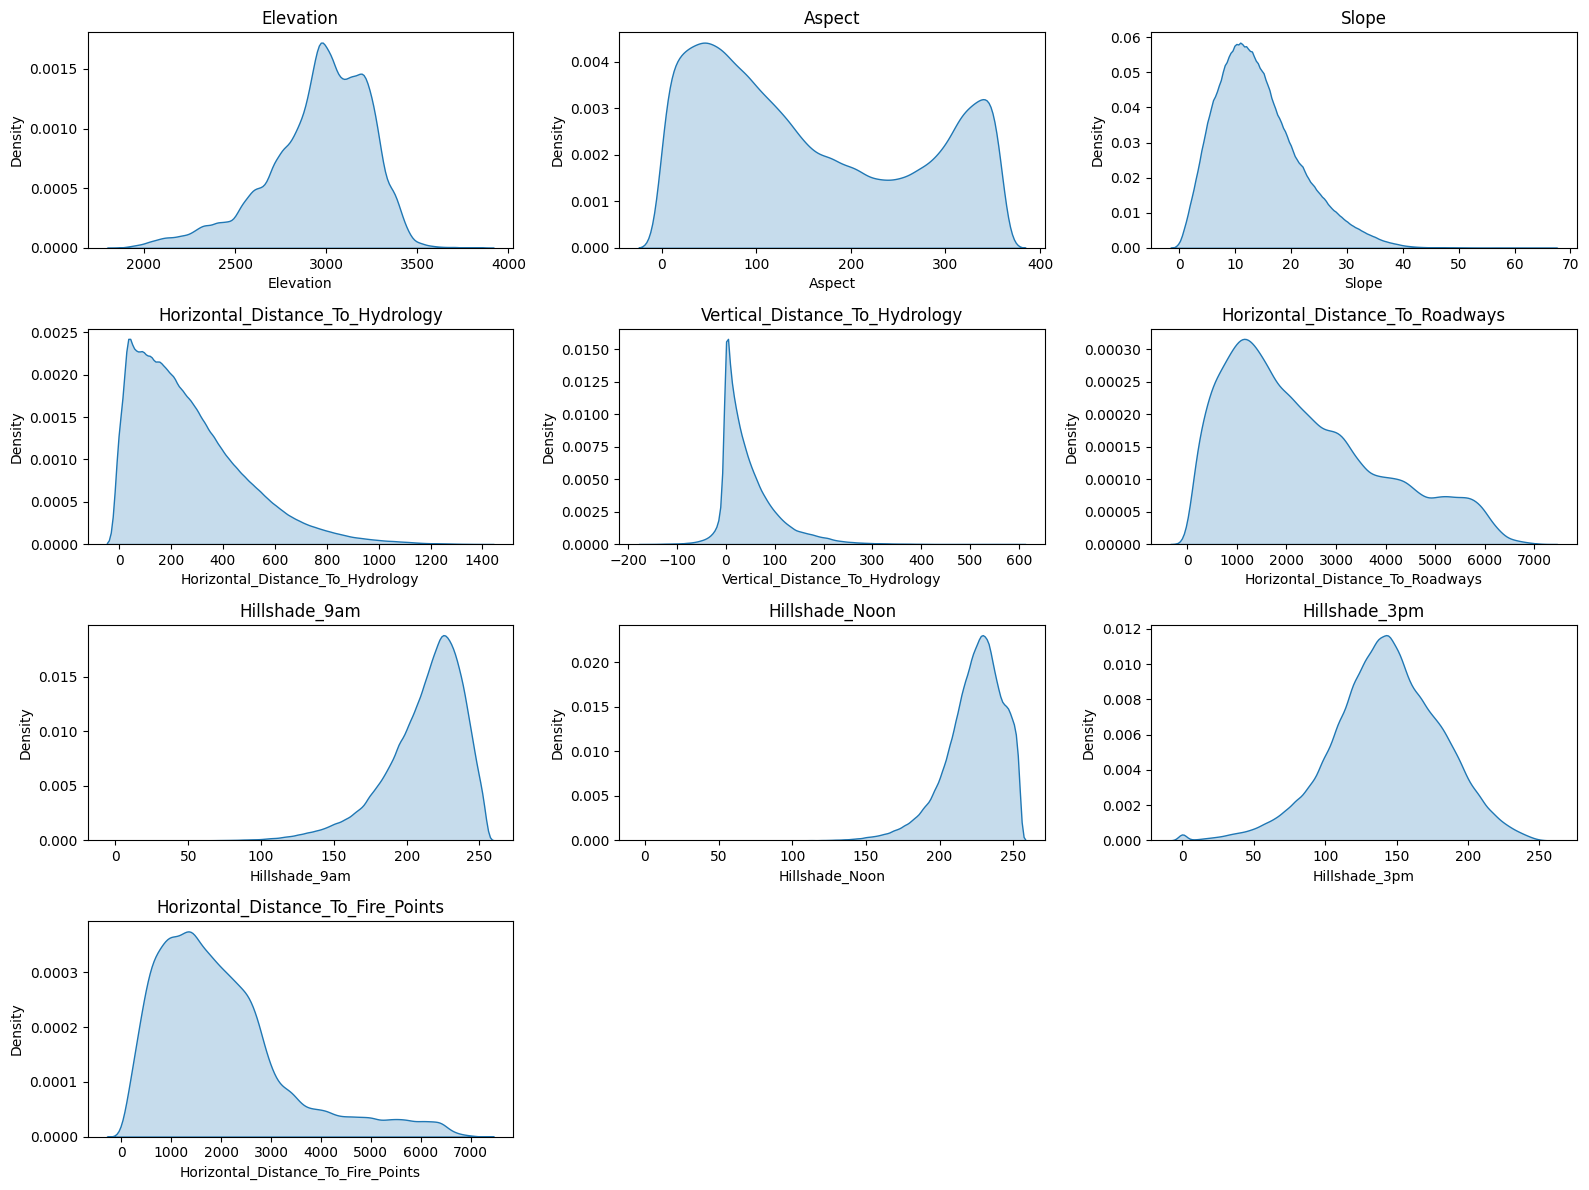

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.kdeplot(df[col], fill=True)
    plt.title(col)

plt.tight_layout()
plt.show()

It seems ther eis some skewness in data

# Display Binary Features

Wilderness columns: ['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']
Soil columns: 40


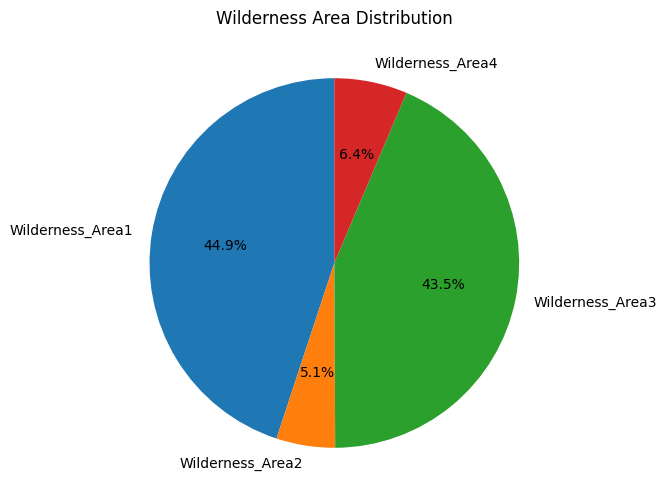

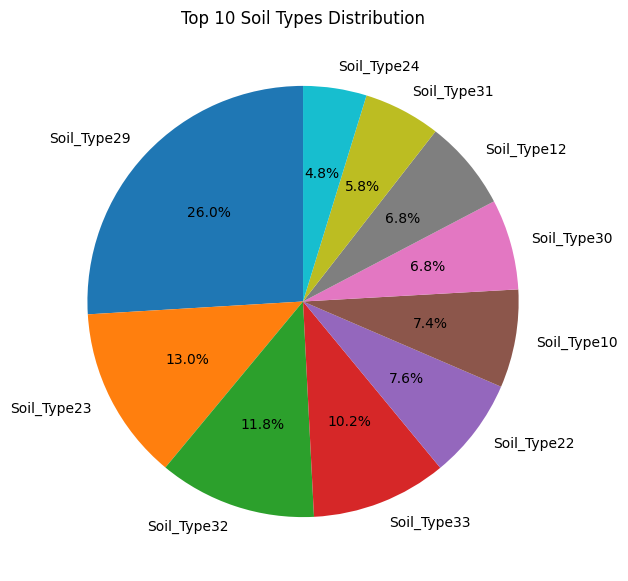

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Identify binary columns
binary_cols = []

for col in df.columns:
    unique_vals = df[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}):
        binary_cols.append(col)

# Split into groups
wilderness_cols = [col for col in binary_cols if "Wilderness" in col]
soil_cols = [col for col in binary_cols if "Soil" in col]

print("Wilderness columns:", wilderness_cols)
print("Soil columns:", len(soil_cols))

#  ---- WILDERNESS ANALYSIS ----
wilderness_counts = df[wilderness_cols].sum()

plt.figure(figsize=(6,6))
plt.pie(
    wilderness_counts,
    labels=wilderness_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Wilderness Area Distribution")
plt.show()

# ---- SOIL ANALYSIS (Top 10) ----
soil_counts = df[soil_cols].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(7,7))
plt.pie(
    soil_counts.values,
    labels=soil_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top 10 Soil Types Distribution")
plt.show()

it seems that wilderness area 1 having the highest distribution across other types and the soil type 29 is the highest one in soils

#Detect Noise by domain knowledge

In [ ]:
def detect_noise_rules(df):

    noise_summary = {}

    # 1. Elevation (above ~5000 are unrealistic and Values ≤ 0 are invalid in this context)
    noise_elevation = df[(df['Elevation'] <= 0) | (df['Elevation'] > 5000)]
    noise_summary['Elevation'] = len(noise_elevation)

    # 2. Aspect (0–360 , direction in degrees = A full circle = 360°)
    noise_aspect = df[(df['Aspect'] < 0) | (df['Aspect'] > 360)]
    noise_summary['Aspect'] = len(noise_aspect)

    # 3. Slope (0–90 where 0° = flat ground and 90° = vertical slope (extreme case) , Values outside this range are physically impossible)
    noise_slope = df[(df['Slope'] < 0) | (df['Slope'] > 90)]
    noise_summary['Slope'] = len(noise_slope)

    # 4. Distances (must be positive)
    noise_hydro = df[df['Horizontal_Distance_To_Hydrology'] < 0]
    noise_road = df[df['Horizontal_Distance_To_Roadways'] < 0]
    noise_fire = df[df['Horizontal_Distance_To_Fire_Points'] < 0]

    noise_summary['Hydrology_Distance'] = len(noise_hydro)
    noise_summary['Road_Distance'] = len(noise_road)
    noise_summary['Fire_Distance'] = len(noise_fire)

    # 5. Hillshade (0–255 , It is measured like pixel intensity where 0 = no light and 255 = maximum light)
    hill_cols = ['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']
    for col in hill_cols:
        noise = df[(df[col] < 0) | (df[col] > 255)]
        noise_summary[col] = len(noise)

    # 6. Wilderness (0/1 , categorical indicators where 1 = present, 0 = not present)
    wilderness_cols = [c for c in df.columns if "Wilderness_Area" in c]
    for col in wilderness_cols:
        noise = df[~df[col].isin([0, 1])]
        noise_summary[col] = len(noise)

    # 7. Soil (0/1)
    soil_cols = [c for c in df.columns if "Soil_Type" in c]
    for col in soil_cols:
        noise = df[~df[col].isin([0, 1])]
        noise_summary[col] = len(noise)

    # 8. Target (The dataset defines only 7 forest types , Anything else is invalid label noise)
    noise_target = df[~df['Cover_Type'].isin([1,2,3,4,5,6,7])]
    noise_summary['Cover_Type'] = len(noise_target)

    # summary
    print("\n===== NOISE SUMMARY =====")
    for k, v in noise_summary.items():
        print(f"{k}: {v} noisy rows")

    return noise_summary

In [ ]:
noise_summary = detect_noise_rules(df)


===== NOISE SUMMARY =====
Elevation: 0 noisy rows
Aspect: 0 noisy rows
Slope: 0 noisy rows
Hydrology_Distance: 0 noisy rows
Road_Distance: 0 noisy rows
Fire_Distance: 0 noisy rows
Hillshade_9am: 0 noisy rows
Hillshade_Noon: 0 noisy rows
Hillshade_3pm: 0 noisy rows
Wilderness_Area1: 0 noisy rows
Wilderness_Area2: 0 noisy rows
Wilderness_Area3: 0 noisy rows
Wilderness_Area4: 0 noisy rows
Soil_Type1: 0 noisy rows
Soil_Type2: 0 noisy rows
Soil_Type3: 0 noisy rows
Soil_Type4: 0 noisy rows
Soil_Type5: 0 noisy rows
Soil_Type6: 0 noisy rows
Soil_Type7: 0 noisy rows
Soil_Type8: 0 noisy rows
Soil_Type9: 0 noisy rows
Soil_Type10: 0 noisy rows
Soil_Type11: 0 noisy rows
Soil_Type12: 0 noisy rows
Soil_Type13: 0 noisy rows
Soil_Type14: 0 noisy rows
Soil_Type15: 0 noisy rows
Soil_Type16: 0 noisy rows
Soil_Type17: 0 noisy rows
Soil_Type18: 0 noisy rows
Soil_Type19: 0 noisy rows
Soil_Type20: 0 noisy rows
Soil_Type21: 0 noisy rows
Soil_Type22: 0 noisy rows
Soil_Type23: 0 noisy rows
Soil_Type24: 0 noisy 

#Detect Nulls

In [ ]:
print("\nMissing values in our data:\n",df.isnull().sum())


Missing values in our data:
 Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type1

In [ ]:
df.dropna(inplace=True)

#Detect Duplicates

In [ ]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


#Detect Skewness

Skewness = direction of distribution (left or right)
* Close to 0 → fairly normal distribution (balanced)
* Positive (+) → right-skewed (few large values)
* Negative (−) → left-skewed (few small values)

Kurtosis = presence of extreme values (outliers)
* Around 0 → normal distribution
* Positive (+) → heavy tails (many outliers)
* Negative (−) → flatter distribution (more uniform values)




In [ ]:
for col in numeric_cols:
    print(
        f"{col}: "
        f"Skewness = {skew(df[col].dropna()):.2f}, "
        f"Kurtosis = {kurtosis(df[col].dropna()):.2f}"
    )

Elevation: Skewness = -0.82, Kurtosis = 0.75
Aspect: Skewness = 0.40, Kurtosis = -1.22
Slope: Skewness = 0.79, Kurtosis = 0.57
Horizontal_Distance_To_Hydrology: Skewness = 1.14, Kurtosis = 1.37
Vertical_Distance_To_Hydrology: Skewness = 1.78, Kurtosis = 5.18
Horizontal_Distance_To_Roadways: Skewness = 0.71, Kurtosis = -0.39
Hillshade_9am: Skewness = -1.18, Kurtosis = 1.89
Hillshade_Noon: Skewness = -1.06, Kurtosis = 2.00
Hillshade_3pm: Skewness = -0.28, Kurtosis = 0.40
Horizontal_Distance_To_Fire_Points: Skewness = 1.29, Kurtosis = 1.64
Elevation: Skewness = -0.82, Kurtosis = 0.75
Aspect: Skewness = 0.40, Kurtosis = -1.22
Slope: Skewness = 0.79, Kurtosis = 0.57
Horizontal_Distance_To_Hydrology: Skewness = 1.14, Kurtosis = 1.37
Vertical_Distance_To_Hydrology: Skewness = 1.78, Kurtosis = 5.18
Horizontal_Distance_To_Roadways: Skewness = 0.71, Kurtosis = -0.39
Hillshade_9am: Skewness = -1.18, Kurtosis = 1.89
Hillshade_Noon: Skewness = -1.06, Kurtosis = 2.00
Hillshade_3pm: Skewness = -0.28,

* Most distance-based features are right-skewed + outlier-heavy
* Hillshade features show left skew with moderate outliers
* Aspect is the most “well-behaved” (low kurtosis, low skew)

#

#Determine correlation between features

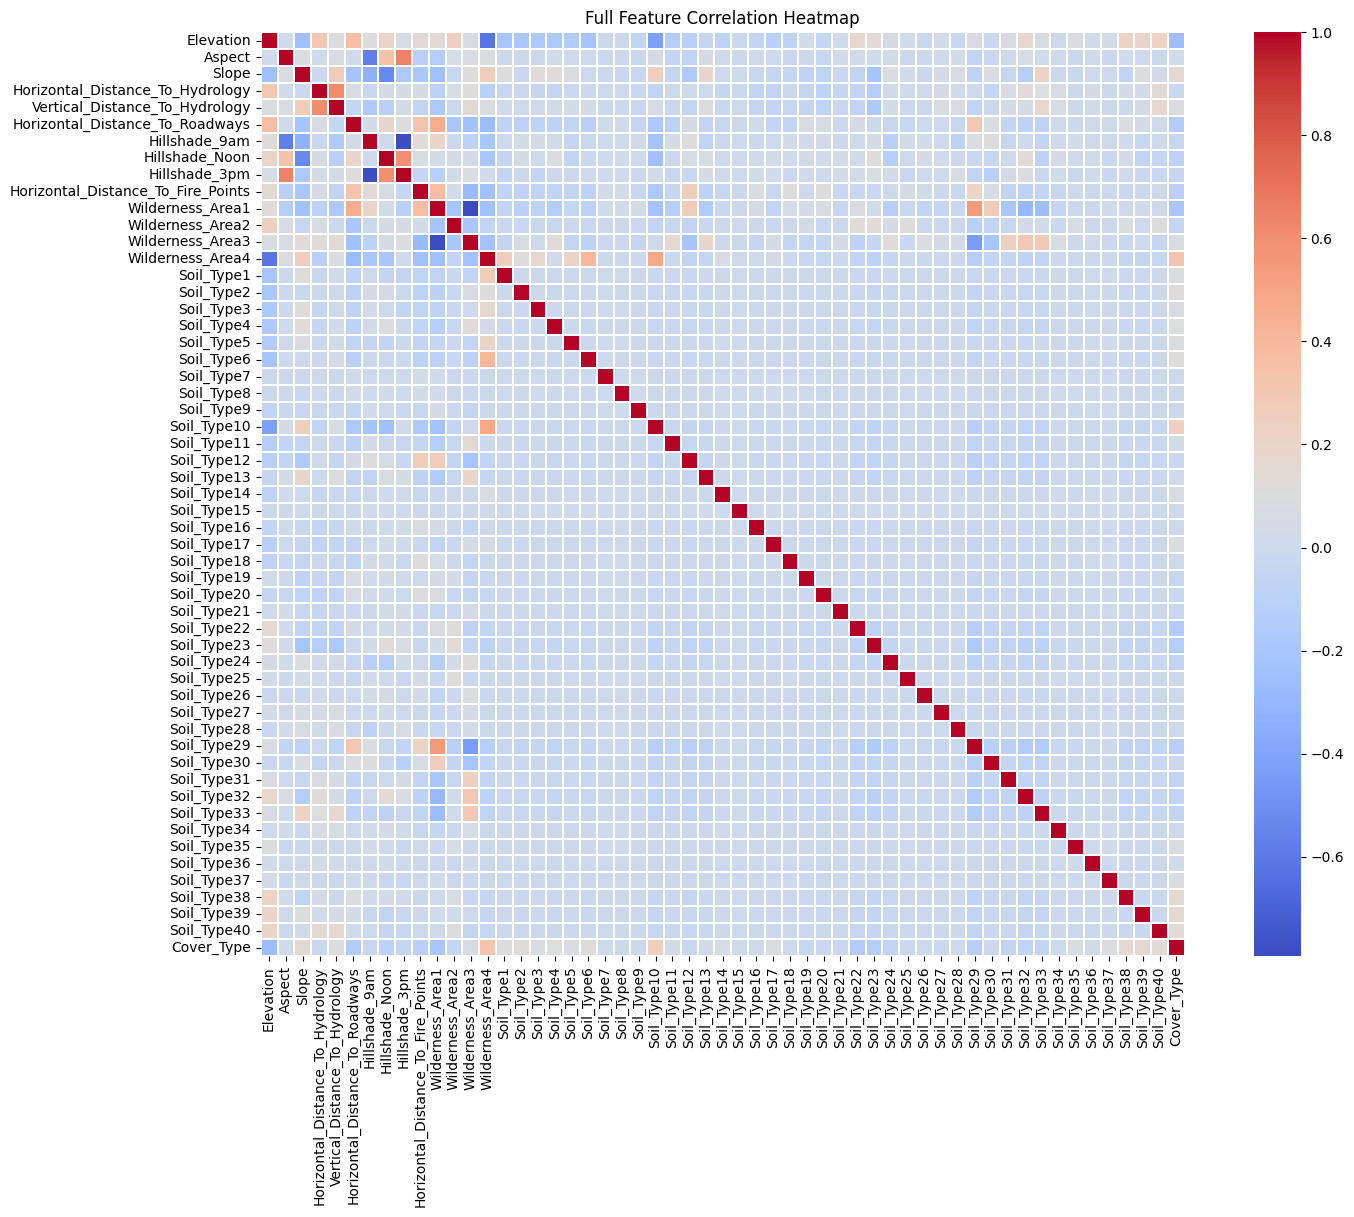

In [ ]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    linewidths=0.2,
    square=True
)

plt.title("Full Feature Correlation Heatmap")
plt.show()

- Features are mostly independent(most values are grey= weakly correlated) ,  good for modeling

- No serious multicollinearity

- few small coloured spots : hillshade features correlate with each other and distance features might relate slightly

- Correlation is NOT enough to understand relationship with target

- Models are needed (like Random Forest) to detect non-linear patterns

# Correlation with target

In [ ]:
df_numeric = df.select_dtypes(include='number')

# correlation matrix
corr = df_numeric.corr()
target_corr = corr['Cover_Type'].drop('Cover_Type')

target_corr_sorted = target_corr.sort_values(ascending=False)

print( "\n Most Positive Correlated Features:")
print(target_corr_sorted.head(10))

print("\n Most Negative Correlated Features:")
print(target_corr_sorted.tail(10))


 Most Positive Correlated Features:
Wilderness_Area4    0.323449
Soil_Type10         0.244047
Soil_Type38         0.160050
Soil_Type39         0.155829
Slope               0.148571
Soil_Type40         0.131596
Soil_Type2          0.116456
Soil_Type6          0.113581
Soil_Type4          0.098547
Soil_Type17         0.091024
Name: Cover_Type, dtype: float64

 Most Negative Correlated Features:
Soil_Type24                          -0.068394
Soil_Type32                          -0.075122
Hillshade_Noon                       -0.096728
Horizontal_Distance_To_Fire_Points   -0.108426
Soil_Type29                          -0.125242
Soil_Type23                          -0.135546
Soil_Type22                          -0.141942
Horizontal_Distance_To_Roadways      -0.152744
Wilderness_Area1                     -0.204175
Elevation                            -0.267642
Name: Cover_Type, dtype: float64


**Positive correlation** → increases the likelihood of a certain forest type
**Negative correlation** → decreases the likelihood of a certain forest type


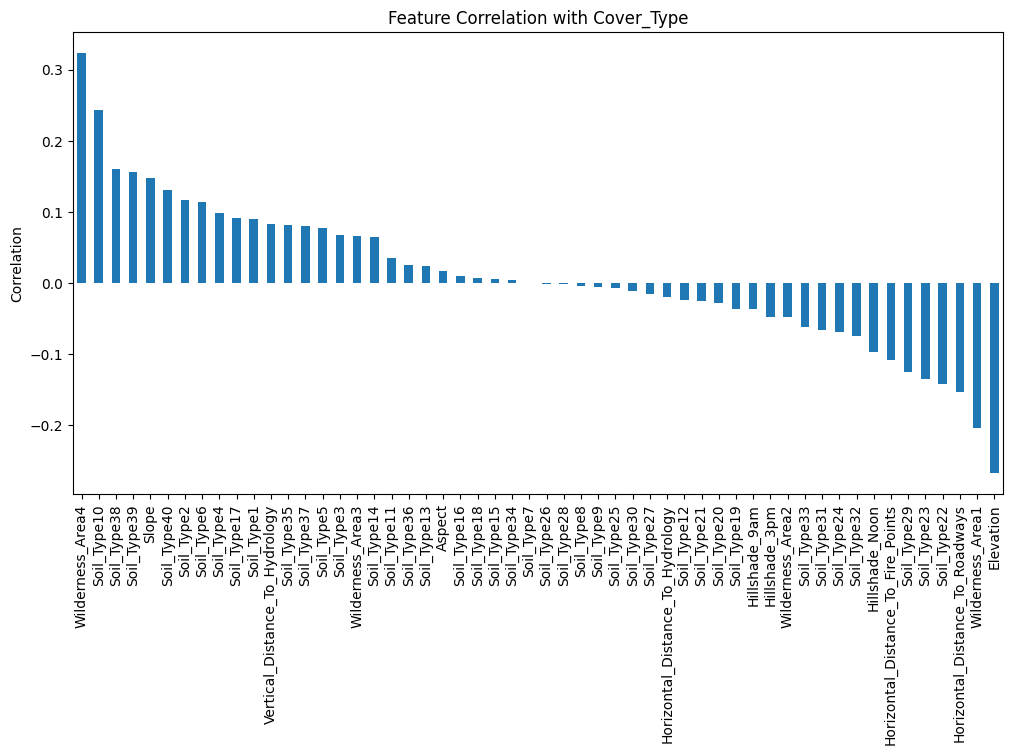

In [ ]:
plt.figure(figsize=(12,6))

target_corr_sorted.plot(kind='bar')

plt.title("Feature Correlation with Cover_Type")
plt.ylabel("Correlation")
plt.xticks(rotation=90)

plt.show()

The type of forest cover is not determined by a single feature, but rather by a combination of soil, elevation, and location

* Soil = the most important factor in determining tree type
* Geographic region = has a moderate impact
* Elevation = has a strong inverse relationship in some cases
* Distances = have a smaller impact overall



#Distribution of Target Variable

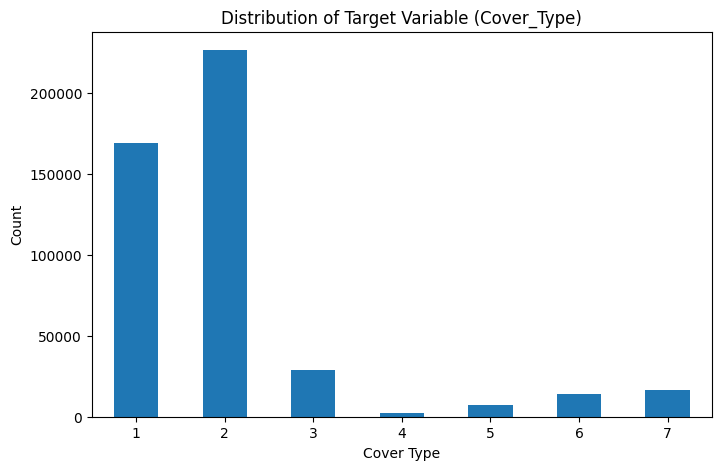

In [ ]:
plt.figure(figsize=(8,5))

df['Cover_Type'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Distribution of Target Variable (Cover_Type)")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()



Class 2 has the highest number of samples
Followed by class 1
The remaining classes (3 → 7) are much smaller
Some classes are very rare (like 4 and 5)

Problem : The dataset is imbalanced , The model sees class 2 much more often
So it tends to favor predicting class 2, even when it’s wrong and this may cause :
Bias toward majority classes (1 and 2)
Poor performance on minority classes
So , Accuracy alone is misleading (not enough to evaluate the model)

Feature vs Cover_Type

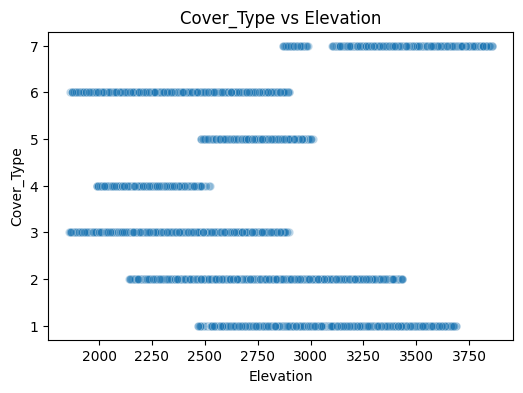

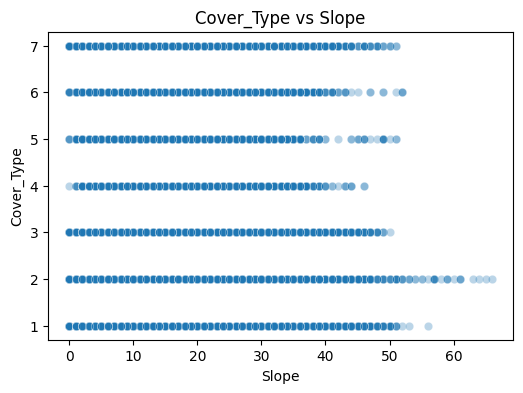

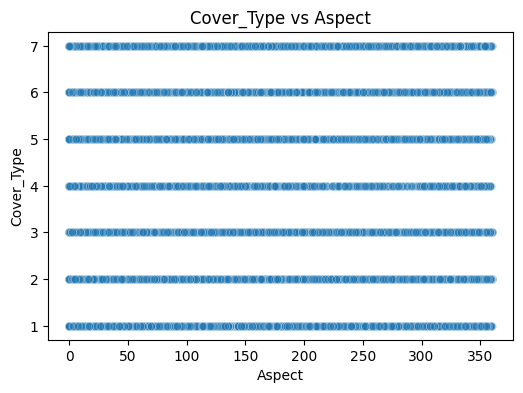

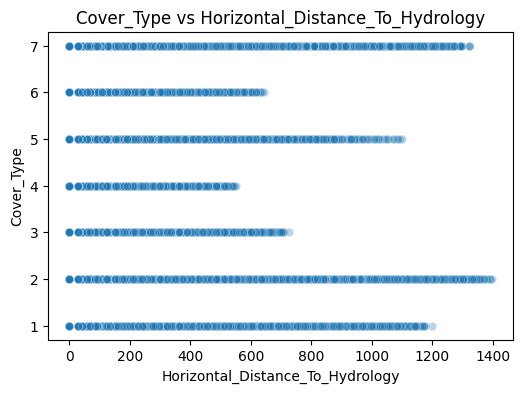

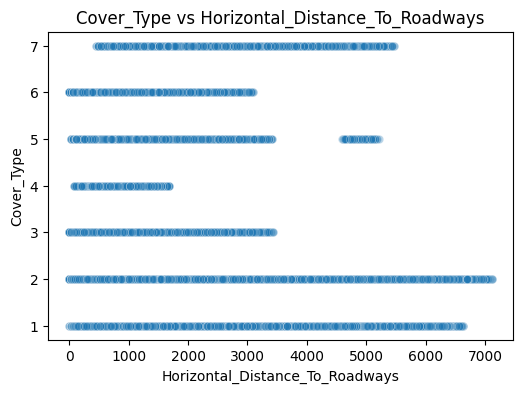

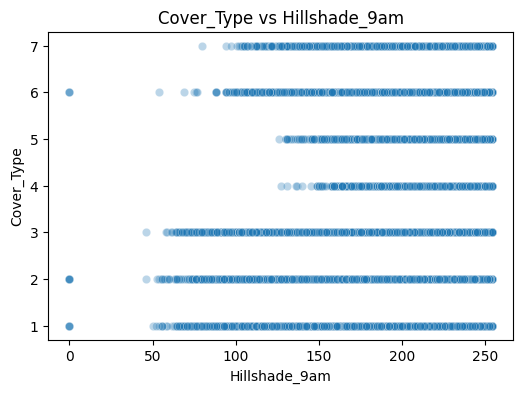

In [ ]:
key_features = [
    'Elevation',
    'Slope',
    'Aspect',
    'Horizontal_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am'
]

for col in key_features:
    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=col,
        y='Cover_Type',
        data=df,
        alpha=0.3
    )

    plt.title(f'Cover_Type vs {col}')
    plt.xlabel(col)
    plt.ylabel('Cover_Type')

    plt.show()



* Strong Feature (Elevation)
Each class appears in a different range = good separation

* Medium Features( Distance to Hydrology , Distance to Roadways , Hillshade)
Some differences, but noticeable overlap

* Weak Features( Slope ,Aspect)
Classes are mixed = poor separation

#Class Imbalance Detection

In [ ]:
counts = df['Cover_Type'].value_counts()

imbalance_ratio = counts.max() / counts.min()

print("Max class:", counts.idxmax(), counts.max())
print("Min class:", counts.idxmin(), counts.min())
print("Imbalance Ratio:", imbalance_ratio)

Max class: 2 226801
Min class: 4 2221
Imbalance Ratio: 102.11661413777577


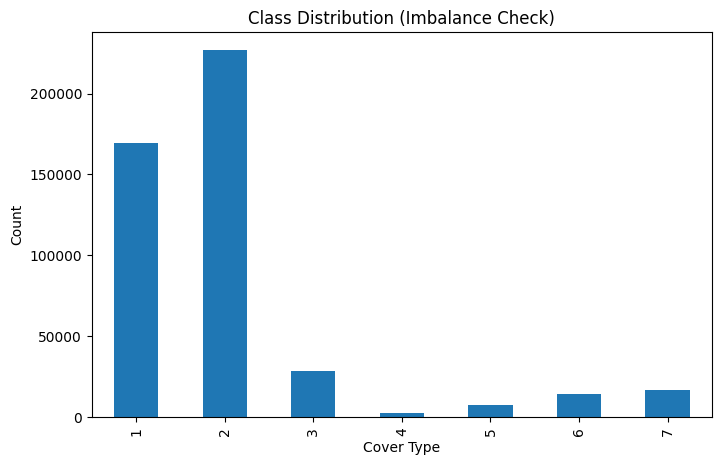

In [ ]:
plt.figure(figsize=(8,5))

df['Cover_Type'].value_counts().sort_index().plot(kind='bar')

plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Cover Type")
plt.ylabel("Count")

plt.show()

#Discover Important Features

In [ ]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
print(feat_imp.head(15))

                               Feature  Importance
0                            Elevation    0.240912
5      Horizontal_Distance_To_Roadways    0.118431
9   Horizontal_Distance_To_Fire_Points    0.111732
3     Horizontal_Distance_To_Hydrology    0.061013
4       Vertical_Distance_To_Hydrology    0.057475
1                               Aspect    0.047829
7                       Hillshade_Noon    0.042941
6                        Hillshade_9am    0.041357
8                        Hillshade_3pm    0.040920
2                                Slope    0.032988
13                    Wilderness_Area4    0.028263
35                         Soil_Type22    0.015807
23                         Soil_Type10    0.012519
17                          Soil_Type4    0.011887
12                    Wilderness_Area3    0.011651


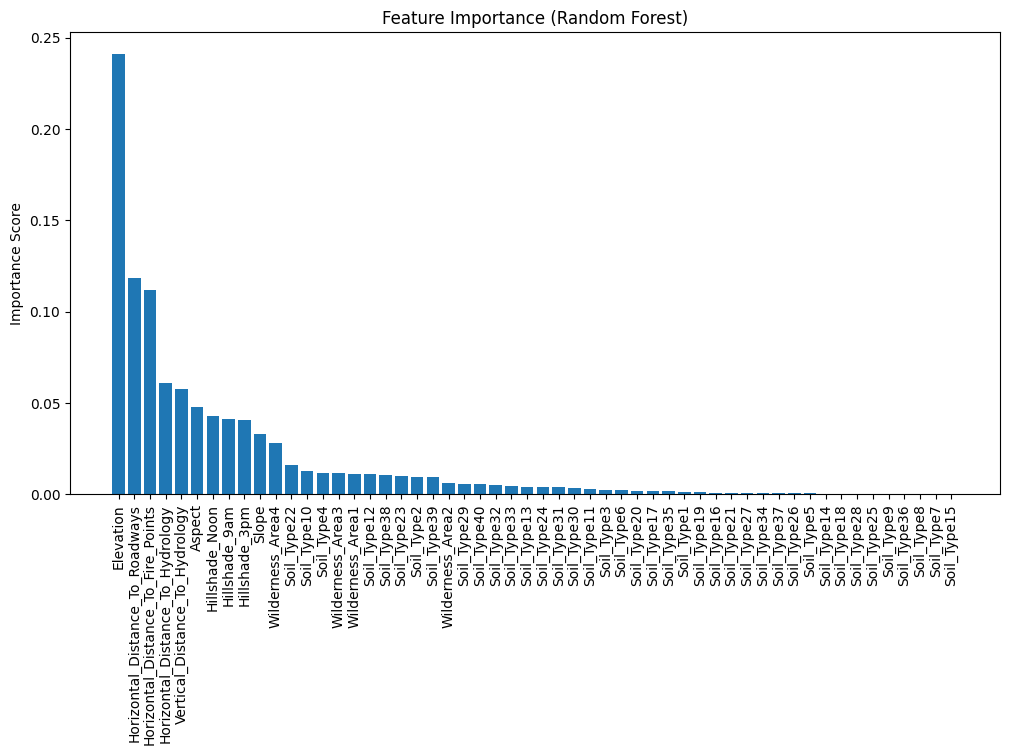

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(feat_imp['Feature'], feat_imp['Importance'])

plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")

plt.show()

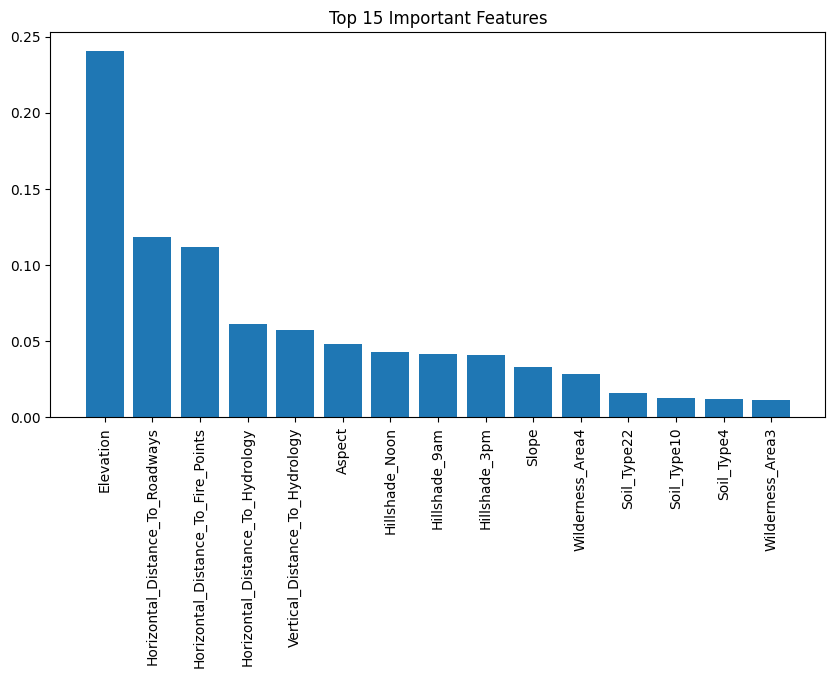

In [ ]:
top15 = feat_imp.head(15)

plt.figure(figsize=(10,5))
plt.bar(top15['Feature'], top15['Importance'])

plt.xticks(rotation=90)
plt.title("Top 15 Important Features")
plt.show()

#KDE Plot: Feature Distribution by Cover_Type

To Compare how a feature is distributed across different forest types using smooth curves

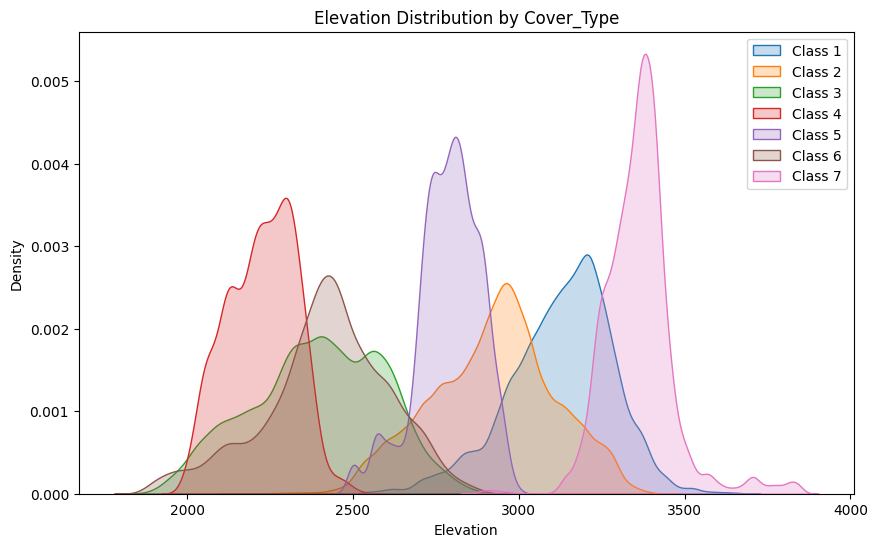

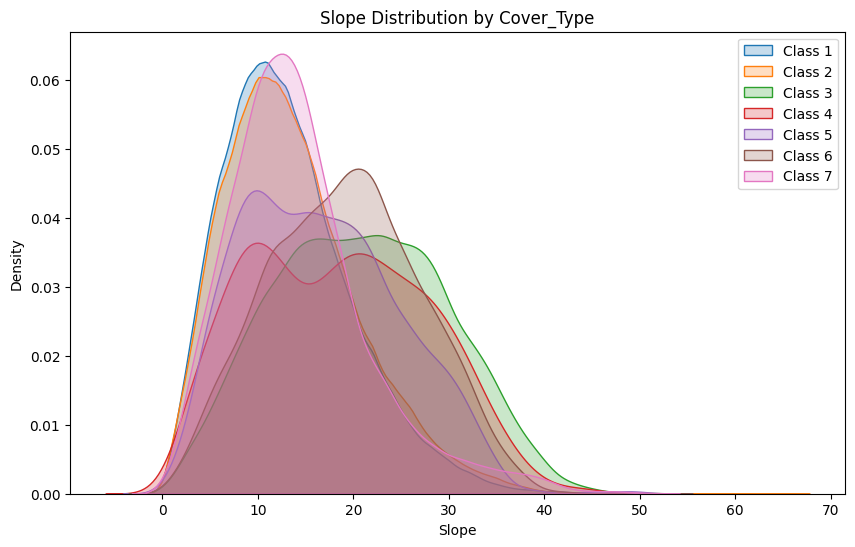

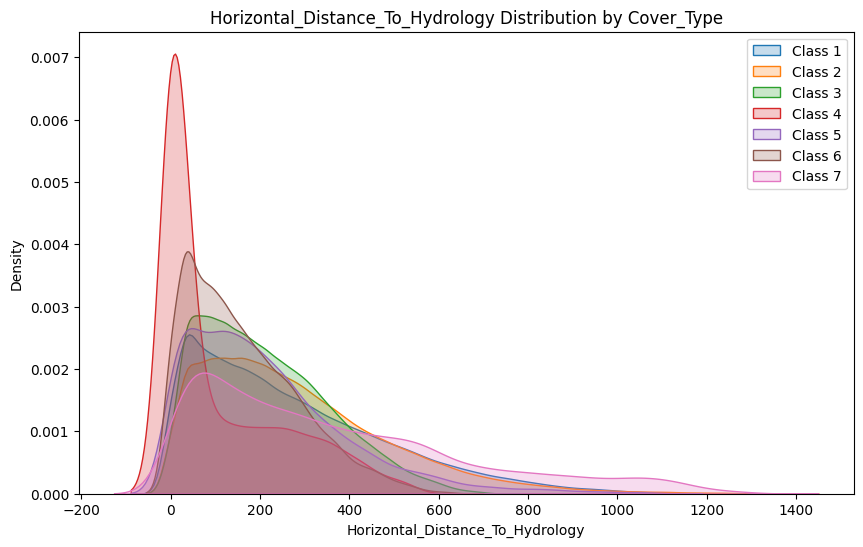

In [ ]:
features = [
    'Elevation',
    'Slope',
    'Horizontal_Distance_To_Hydrology'
]

for col in features:
    plt.figure(figsize=(10,6))

    for cls in sorted(df['Cover_Type'].unique()):
        sns.kdeplot(
            df[df['Cover_Type'] == cls][col],
            label=f'Class {cls}',
            fill=True,
            alpha=0.25
        )

    plt.title(f'{col} Distribution by Cover_Type')
    plt.legend()
    plt.show()

#Detect Similarity between tree types

In [ ]:
class_profiles = df.groupby("Cover_Type").mean()

In [ ]:
scaler = StandardScaler() #rescales the data so all features have the same scale
scaled_profiles = scaler.fit_transform(class_profiles)

In [ ]:
similarity_matrix = cosine_similarity(scaled_profiles)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=class_profiles.index,
    columns=class_profiles.index
)

similarity_df

Cover_Type,1,2,3,4,5,6,7
Cover_Type,,,,,,,
1,1.000000,0.433715,-0.614805,-0.521319,-0.084166,-0.482716,0.110881
2,0.433715,1.000000,-0.612740,-0.526789,0.136134,-0.478886,-0.096561
3,-0.614805,-0.612740,1.000000,0.356141,-0.255425,0.589478,-0.253967
4,-0.521319,-0.526789,0.356141,1.000000,-0.176891,0.278985,-0.354237
5,-0.084166,0.136134,-0.255425,-0.176891,1.000000,-0.316860,-0.202482
6,-0.482716,-0.478886,0.589478,0.278985,-0.316860,1.000000,-0.381146
7,0.110881,-0.096561,-0.253967,-0.354237,-0.202482,-0.381146,1.000000


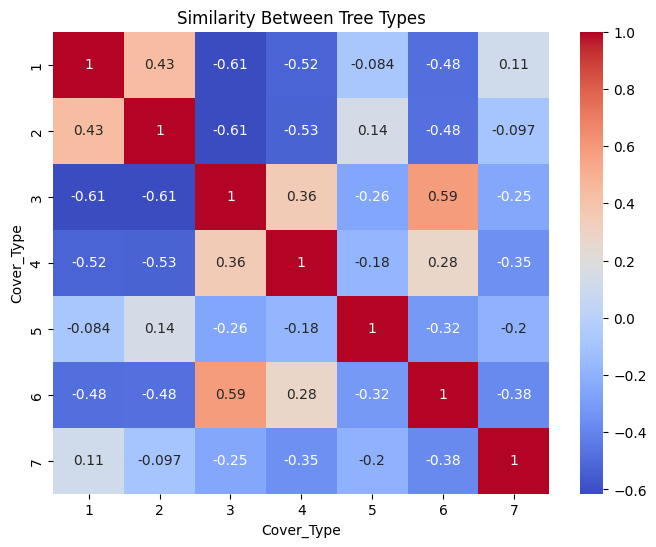

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm")
plt.title("Similarity Between Tree Types")
plt.show()

In [ ]:
print(df['Cover_Type'].value_counts())

Cover_Type
2    226801
1    169283
3     28633
7     16495
6     13878
5      7498
4      2221
Name: count, dtype: int64


In [ ]:
#solving imbalance by unbalanced randomforest
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.96      0.94      0.95     33857
           2       0.95      0.97      0.96     45360
           3       0.93      0.96      0.94      5727
           4       0.93      0.86      0.89       444
           5       0.94      0.75      0.83      1499
           6       0.93      0.87      0.90      2776
           7       0.97      0.93      0.95      3299

    accuracy                           0.95     92962
   macro avg       0.94      0.90      0.92     92962
weighted avg       0.95      0.95      0.95     92962



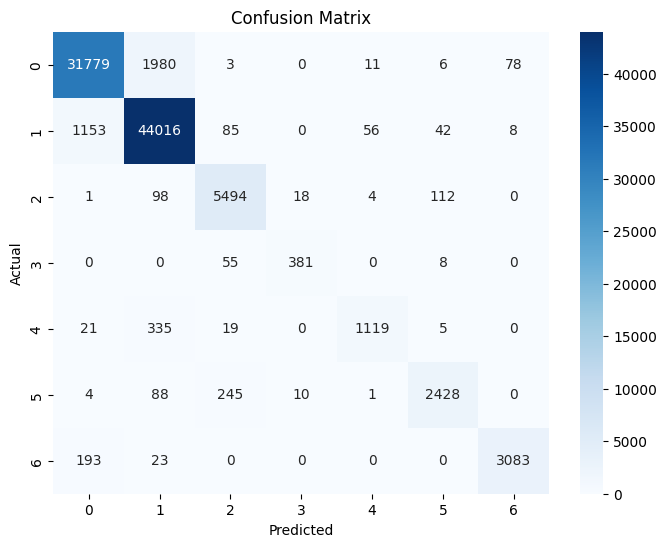

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#solving unbalaned by balanced randomforest
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred_new = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           1       0.96      0.94      0.95     33857
           2       0.95      0.97      0.96     45360
           3       0.93      0.96      0.94      5727
           4       0.94      0.84      0.89       444
           5       0.94      0.76      0.84      1499
           6       0.93      0.87      0.90      2776
           7       0.97      0.94      0.95      3299

    accuracy                           0.95     92962
   macro avg       0.94      0.90      0.92     92962
weighted avg       0.95      0.95      0.95     92962



In [ ]:
print("Before Fix:")
print(classification_report(y_test, y_pred))

print("After Fix:")
print(classification_report(y_test, y_pred_new))

Before Fix:
              precision    recall  f1-score   support

           1       0.96      0.94      0.95     33857
           2       0.95      0.97      0.96     45360
           3       0.93      0.96      0.94      5727
           4       0.93      0.86      0.89       444
           5       0.94      0.75      0.83      1499
           6       0.93      0.87      0.90      2776
           7       0.97      0.93      0.95      3299

    accuracy                           0.95     92962
   macro avg       0.94      0.90      0.92     92962
weighted avg       0.95      0.95      0.95     92962

After Fix:
              precision    recall  f1-score   support

           1       0.96      0.94      0.95     33857
           2       0.95      0.97      0.96     45360
           3       0.93      0.96      0.94      5727
           4       0.94      0.84      0.89       444
           5       0.94      0.76      0.84      1499
           6       0.93      0.87      0.90      2776
 

In [ ]:
print(df['Cover_Type'].value_counts())

Cover_Type
2    226801
1    169283
3     28633
7     16495
6     13878
5      7498
4      2221
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

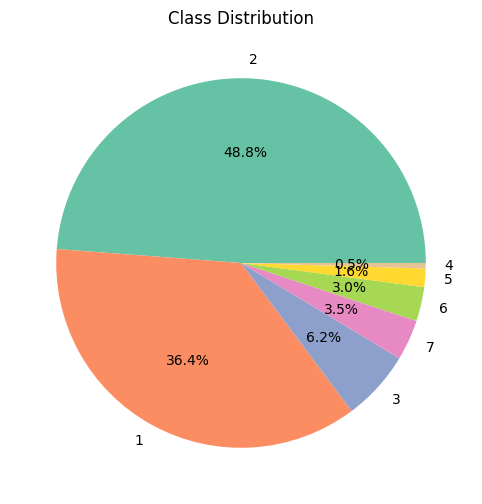

In [ ]:
cmap = sns.color_palette('Set2', as_cmap=True)(np.arange(7))
plt.figure(figsize=(8,6))
plt.pie(
    df['Cover_Type'].value_counts().values,
    colors=cmap,
    labels=df['Cover_Type'].value_counts().keys(),
    autopct='%1.1f%%'
)
plt.title('Class Distribution')
plt.show

In [ ]:

from xgboost import XGBClassifier

# 1. Load data
df = pd.read_csv("covtype.csv")

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"] - 1   # convert labels to 0–6

# 2. Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Model (strong + simple + handles imbalance well)
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
preds = model.predict(X_val)

# 6. Evaluate
print(classification_report(y_val, preds, digits=4))

              precision    recall  f1-score   support

           0     0.8650    0.8391    0.8519     42368
           1     0.8683    0.8991    0.8834     56661
           2     0.8940    0.9168    0.9053      7151
           3     0.8715    0.8397    0.8553       549
           4     0.8994    0.6356    0.7448      1899
           5     0.8583    0.8091    0.8330      3473
           6     0.9474    0.9135    0.9301      4102

    accuracy                         0.8715    116203
   macro avg     0.8863    0.8361    0.8577    116203
weighted avg     0.8717    0.8715    0.8710    116203



In [ ]:
data = pd.read_csv("covtype.csv")

In [ ]:
# Start class labels from 0 rather than 1
data['Cover_Type'] = data['Cover_Type'] - 1

In [ ]:
data['Cover_Type'].head()

,Cover_Type
0,4
1,4
2,1
3,1
4,4


In [ ]:
data['Cover_Type'].value_counts()


,count
Cover_Type,
1,283301
0,211840
2,35754
6,20510
5,17367
4,9493
3,2747


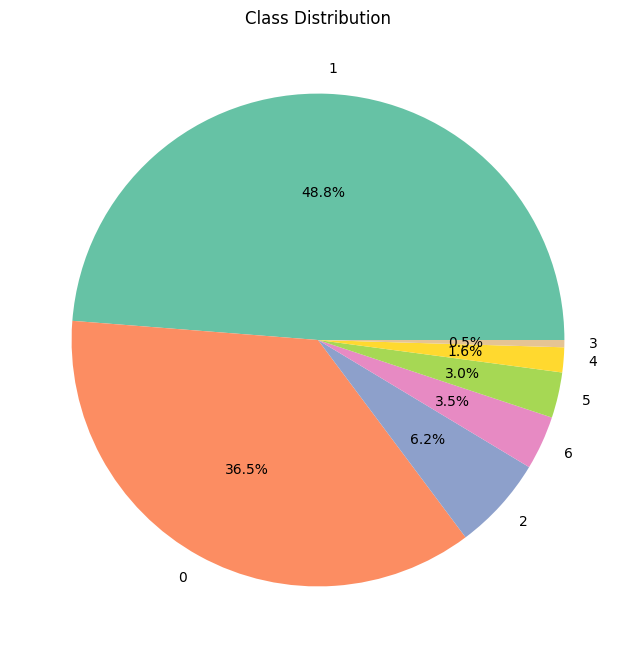

In [ ]:
cmap = sns.color_palette('Set2', as_cmap=True)(np.arange(7))

plt.figure(figsize=(8, 8))
plt.pie(
    data['Cover_Type'].value_counts().values,
    colors=cmap,
    labels=data['Cover_Type'].value_counts().keys(),
    autopct='%.1f%%'
)
plt.title("Class Distribution")
plt.show()

#Handeling Imbalance

Using RandomForest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#  COMPUTE CLASS WEIGHTS
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

#  MODEL (HANDLES IMBALANCE)
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# TRAIN
model.fit(X_train, y_train)

# PREDICT
y_pred = model.predict(X_test)

# EVALUATE
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9663    0.9427    0.9544     42368
           1     0.9495    0.9745    0.9619     56661
           2     0.9386    0.9613    0.9498      7151
           3     0.9105    0.8525    0.8805       549
           4     0.9482    0.7899    0.8618      1899
           5     0.9359    0.8906    0.9127      3473
           6     0.9737    0.9481    0.9607      4102

    accuracy                         0.9551    116203
   macro avg     0.9461    0.9085    0.9260    116203
weighted avg     0.9552    0.9551    0.9549    116203



Class distribution:
Class 1: 211840
Class 2: 283301
Class 3: 35754
Class 4: 2747
Class 5: 9493
Class 6: 17367
Class 7: 20510

 Imbalance analysis:
Max class count: 283301
Min class count: 2747
Imbalance ratio (max/min): 103.13

 Strong imbalance (needs fixing)


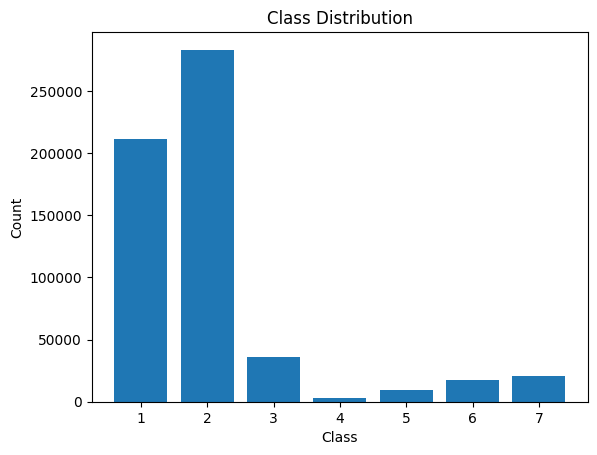

In [ ]:
y = df["Cover_Type"]

def check_imbalance(y):
    y = np.array(y)

    # 1. Count each class
    values, counts = np.unique(y, return_counts=True)

    print("Class distribution:")
    for v, c in zip(values, counts):
        print(f"Class {v}: {c}")

    # 2. Basic stats
    max_count = np.max(counts)
    min_count = np.min(counts)
    ratio = max_count / min_count

    print("\n Imbalance analysis:")
    print("Max class count:", max_count)
    print("Min class count:", min_count)
    print("Imbalance ratio (max/min):", round(ratio, 2))

    # 3. Decision
    if ratio < 1.5:
        print("\n Dataset is BALANCED")
    elif ratio < 5:
        print("\n Mild imbalance")
    else:
        print("\n Strong imbalance (needs fixing)")

    # 4. Plot distribution
    plt.bar(values, counts)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

check_imbalance(y)

In [ ]:
values, counts = np.unique(y, return_counts=True)

for v, c in zip(values, counts):
    print(f"Class {v} → {c}")

Class 1 → 211840
Class 2 → 283301
Class 3 → 35754
Class 4 → 2747
Class 5 → 9493
Class 6 → 17367
Class 7 → 20510


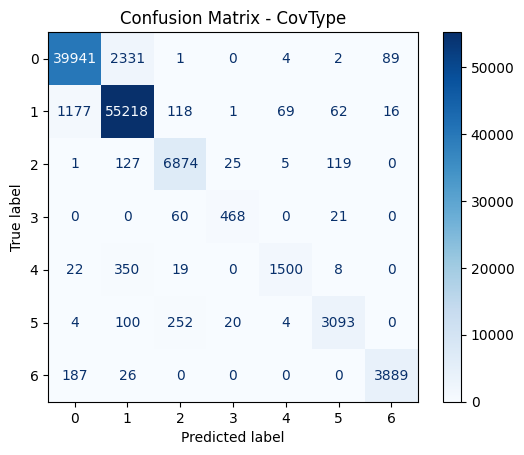

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - CovType")
plt.show()

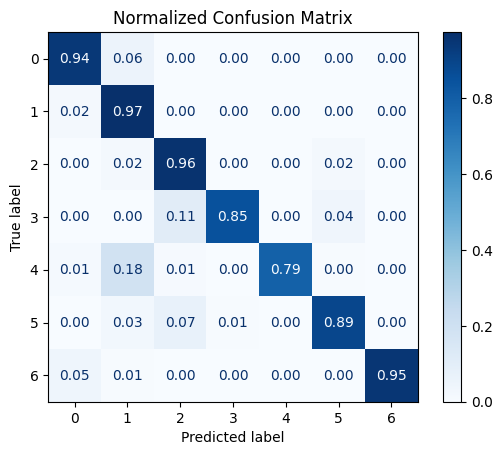

In [ ]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap="Blues", values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

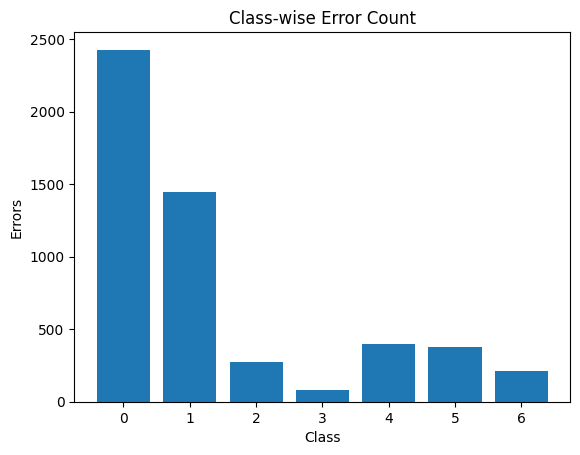

In [ ]:
cm = confusion_matrix(y_test, y_pred)
error_rate = cm.sum(axis=1) - np.diag(cm)

classes = np.unique(y_test)

plt.bar(classes, error_rate)
plt.title("Class-wise Error Count")
plt.xlabel("Class")
plt.ylabel("Errors")
plt.show()

In [ ]:
errors = pd.DataFrame({
    "True": y_test,
    "Pred": y_pred
})

wrong = errors[errors["True"] != errors["Pred"]]

print(wrong.head(20))

        True  Pred
308639     5     2
6399       3     2
3148       4     1
100259     1     0
241589     5     2
61435      0     1
306625     0     1
559968     1     0
72830      0     1
94537      0     1
94894      0     1
76421      1     0
241496     5     1
502963     0     1
497409     0     6
567665     5     1
164188     0     1
131957     0     1
163174     0     1
343750     0     1


Using SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Cover_Type
1    226640
0    169472
2     28603
6     16408
5     13894
4      7594
3      2198
Name: count, dtype: int64
After SMOTE: Cover_Type
1    226640
6    226640
0    226640
4    226640
2    226640
3    226640
5    226640
Name: count, dtype: int64


In [ ]:
class_counts = y_train_res.value_counts().sort_index()
print(class_counts)

Cover_Type
0    226640
1    226640
2    226640
3    226640
4    226640
5    226640
6    226640
Name: count, dtype: int64


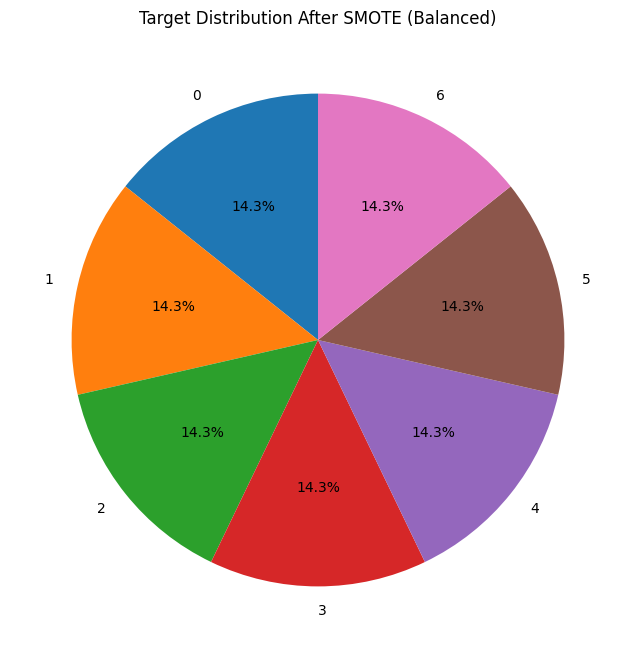

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Target Distribution After SMOTE (Balanced)")
plt.show()

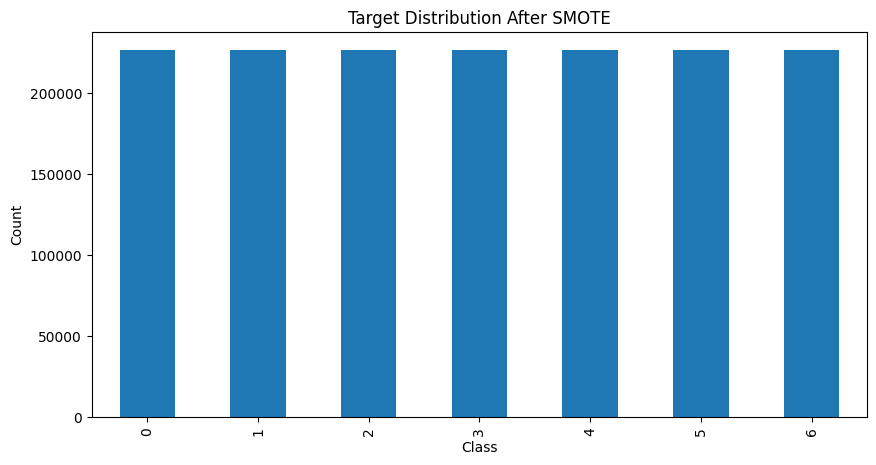

In [ ]:
plt.figure(figsize=(10,5))
class_counts.plot(kind='bar')
plt.title("Target Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#Handeling Outliers

In [ ]:
X_train_clipped = X_train.copy()

for col in X_train.columns:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    X_train_clipped[col] = X_train[col].clip(lower, upper)

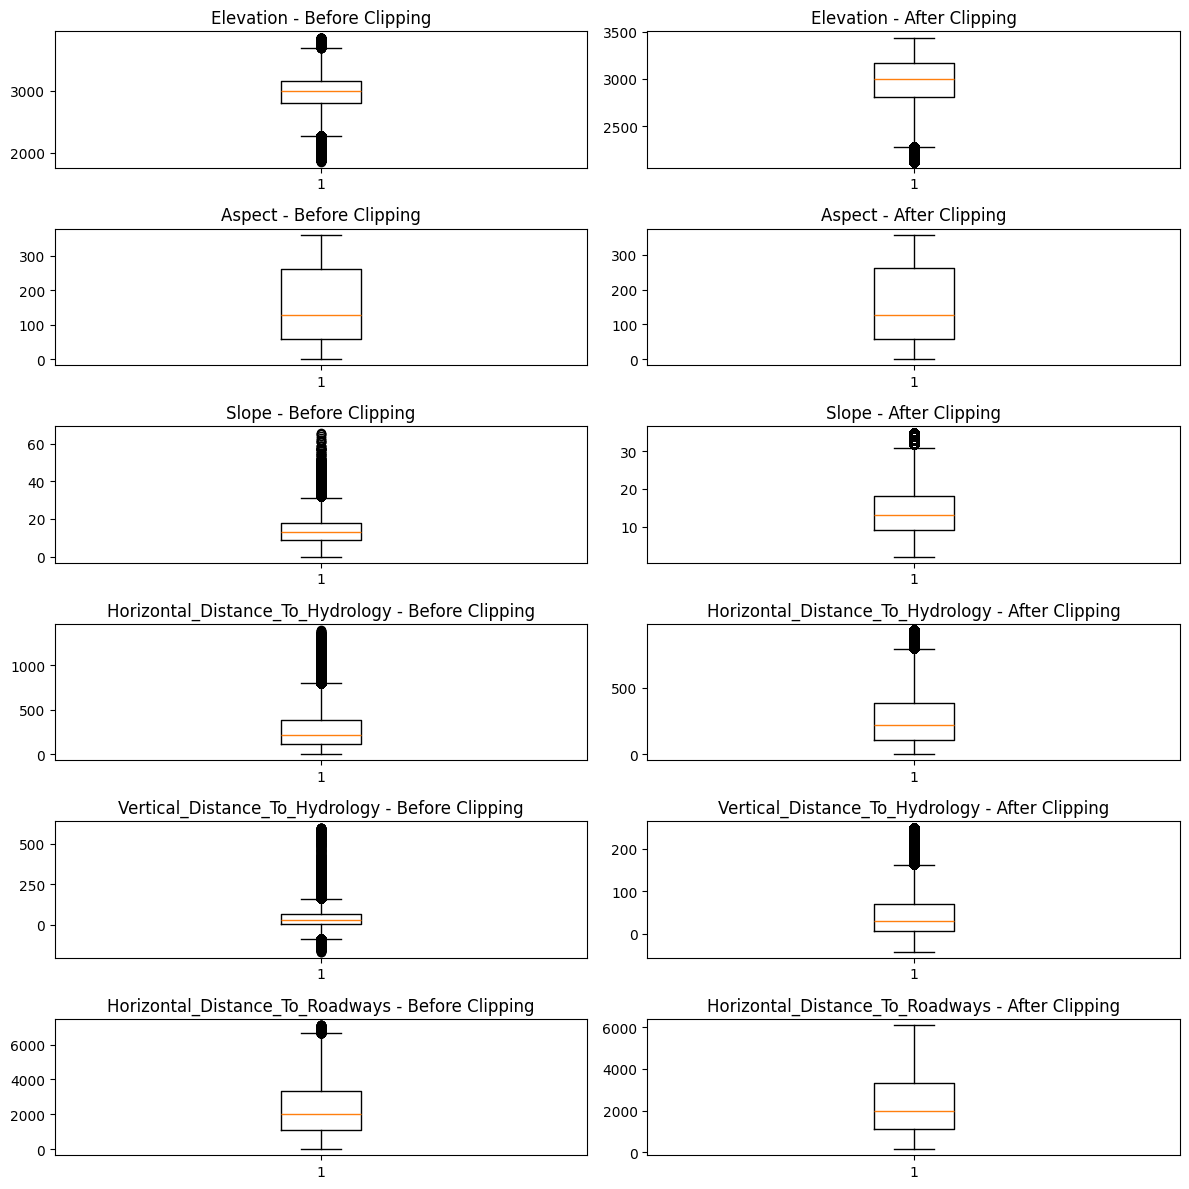

In [ ]:
# Select a few features (important: Covtype has many columns)
cols_to_plot = X_train.columns[:6]  # first 6 features only

fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(12, 12))

for i, col in enumerate(cols_to_plot):

    # BEFORE clipping
    axes[i, 0].boxplot(X_train[col])
    axes[i, 0].set_title(f"{col} - Before Clipping")

    # AFTER clipping
    axes[i, 1].boxplot(X_train_clipped[col])
    axes[i, 1].set_title(f"{col} - After Clipping")

plt.tight_layout()
plt.show()

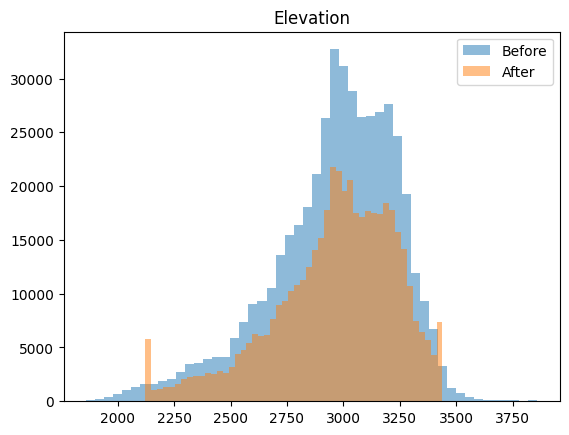

In [ ]:
col = X_train.columns[0]

plt.hist(X_train[col], bins=50, alpha=0.5, label="Before")
plt.hist(X_train_clipped[col], bins=50, alpha=0.5, label="After")
plt.legend()
plt.title(col)
plt.show()

In [ ]:
print("Max before:", X_train.max().max())
print("Max after:", X_train_clipped.max().max())

print("Min before:", X_train.min().min())
print("Min after:", X_train_clipped.min().min())

Max before: 7172
Max after: 6264
Min before: -166
Min after: -42


#Scaling Data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # NEVER fit on test

In [ ]:
import numpy as np

print("Mean after scaling (train):", np.mean(X_train_scaled, axis=0)[:5])
print("Std after scaling (train):", np.std(X_train_scaled, axis=0)[:5])

Mean after scaling (train): [-4.14623009e-16  4.00207587e-17 -7.94682636e-17  5.49253575e-17
  3.65353756e-17]
Std after scaling (train): [1. 1. 1. 1. 1.]


In [ ]:
pd.DataFrame(X_train).head()          # original
pd.DataFrame(X_train_scaled).head()   # scaled

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,0.755252,0.206925,0.787406,0.003068,0.027120,0.260485,0.406155,1.248611,0.116390,0.917245,...,-0.214767,-0.315913,-0.290205,-0.052775,-0.057298,-0.013916,-0.022539,-0.165707,-0.156514,-0.124342
1,0.383857,0.421250,1.588777,-1.268183,-0.797161,0.669635,-0.527975,1.450951,0.874223,-0.897553,...,-0.214767,-0.315913,3.445840,-0.052775,-0.057298,-0.013916,-0.022539,-0.165707,-0.156514,-0.124342
2,1.508757,1.600035,-1.349584,-0.505432,-0.402193,0.701058,-0.042228,0.540423,0.508372,0.210819,...,-0.214767,-0.315913,-0.290205,-0.052775,17.452631,-0.013916,-0.022539,-0.165707,-0.156514,-0.124342
3,0.383857,0.778458,-0.681775,-0.561932,-0.522401,0.295756,-0.341149,1.198026,1.031016,-1.011639,...,-0.214767,-0.315913,-0.290205,-0.052775,-0.057298,-0.013916,-0.022539,-0.165707,-0.156514,-0.124342
4,-0.855320,-0.864698,0.653844,-0.505432,-0.093088,-1.395995,0.667711,-1.381801,-1.373145,-0.096684,...,-0.214767,-0.315913,-0.290205,-0.052775,-0.057298,-0.013916,-0.022539,-0.165707,-0.156514,-0.124342


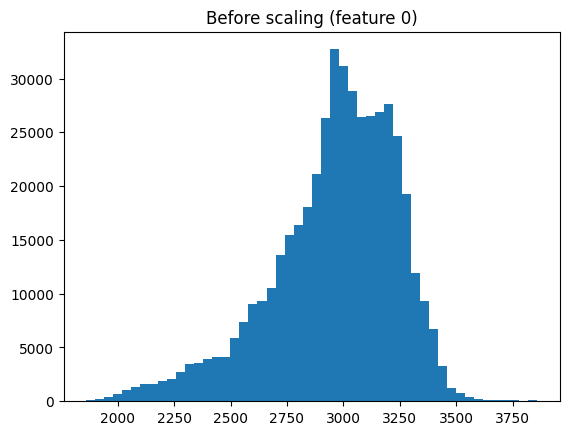

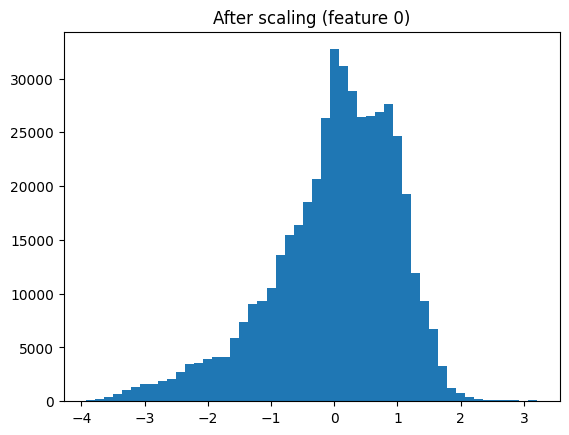

In [ ]:
plt.figure()
plt.hist(X_train.iloc[:, 0], bins=50)
plt.title("Before scaling (feature 0)")
plt.show()

plt.figure()
plt.hist(X_train_scaled[:, 0], bins=50)
plt.title("After scaling (feature 0)")
plt.show()

In [ ]:
print("Min:", np.min(X_train_scaled))
print("Max:", np.max(X_train_scaled))

Min: -11.296430411024684
Max: 393.6182583841016


In [ ]:
print("Original:\n", X_train.iloc[:, 0].head())
print("\nScaled:\n", X_train_scaled[:, 0][:5])

Original:
 261834    3171
549114    3067
7085      3382
436844    3067
177145    2720
Name: Elevation, dtype: int64

Scaled:
 [ 0.75525225  0.38385654  1.508757    0.38385654 -0.85531953]
